In [1]:
# Cellule 1 : Imports et outils de base
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Cellule 2 : Chargement des données
csv_path = r"C:\\Users\\zizou\\OneDrive\\Desktop\\stage 3ème\\day 2\\csvfiles\\dataframefinale.csv"
df = pd.read_csv(csv_path, sep=';', encoding='utf-8-sig')
print(df.columns)
df.info()
df.head()

Index(['dataloadingdate', 'Jour', 'Mois', 'NumeroSemaine', 'Trimestre',
       'JourSemaineNum', 'JourSemaine', 'ISIN', 'Libellé', 'Nombre de Titres',
       'Montant', 'Echéance', 'Taux'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20190 entries, 0 to 20189
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataloadingdate   20190 non-null  object 
 1   Jour              20190 non-null  int64  
 2   Mois              20190 non-null  int64  
 3   NumeroSemaine     20190 non-null  int64  
 4   Trimestre         20190 non-null  int64  
 5   JourSemaineNum    20190 non-null  int64  
 6   JourSemaine       20190 non-null  object 
 7   ISIN              20190 non-null  object 
 8   Libellé           20190 non-null  object 
 9   Nombre de Titres  20190 non-null  float64
 10  Montant           20190 non-null  float64
 11  Echéance          20190 non-null  float64
 12  Taux            

,dataloadingdate,Jour,Mois,NumeroSemaine,Trimestre,JourSemaineNum,JourSemaine,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.6
1,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.5
2,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.6
3,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.6
4,01/07/2025,1,7,27,3,1,Tuesday,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.1


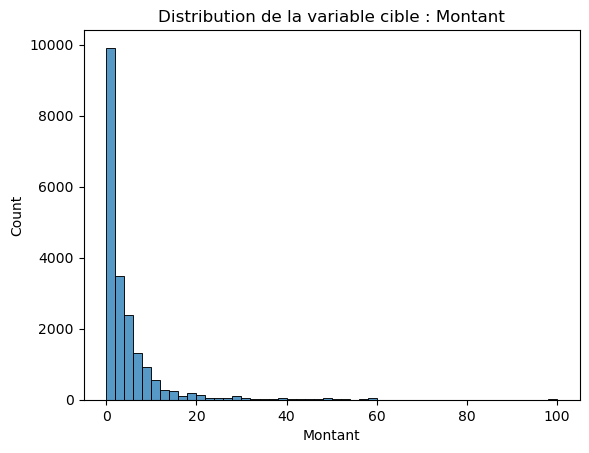

In [3]:
# Cellule 3 : Contrôle et visualisation rapide de la cible (Montant)
sns.histplot(df['Montant'], bins=50)
plt.title("Distribution de la variable cible : Montant")
plt.show()

In [4]:
# Cellule 4 : Préparation X et y, et encodage si besoin
X = df.drop(['Montant'], axis=1)
y = df['Montant']

# Encodage des variables catégorielles si besoin
X = pd.get_dummies(X, drop_first=True)
print("Shape X:", X.shape, "Shape y:", y.shape)

Shape X: (20190, 1326) Shape y: (20190,)


In [5]:
# Cellule 5 : Split train/test (80/20, random_state pour reproductibilité)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size :", X_train.shape, "Test size :", X_test.shape)

Train size : (16152, 1326) Test size : (4038, 1326)


In [6]:
# Cellule 6 : Normalisation StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Cellule 7 : Feature Selection (top 10 variables les plus corrélées)
k_features = min(10, X_train.shape[1])
selector = SelectKBest(f_regression, k=k_features)
X_train_fs = selector.fit_transform(X_train_scaled, y_train)
X_test_fs = selector.transform(X_test_scaled)

In [8]:
# Linear Regression - Baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Linear Regression RMSE (baseline) : {rmse:.4f}")

Linear Regression RMSE (baseline) : 26496.5812


In [9]:
# Ridge Regression - Baseline
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Ridge Regression RMSE (baseline) : {rmse:.4f}")

Ridge Regression RMSE (baseline) : 5.8696


In [10]:
# Lasso Regression - Baseline
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Lasso Regression RMSE (baseline) : {rmse:.4f}")

Lasso Regression RMSE (baseline) : 6.8796


In [11]:
# Random Forest - Baseline
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Random Forest RMSE (baseline) : {rmse:.4f}")

Random Forest RMSE (baseline) : 2.5516


In [12]:
# HistGradientBoosting - Baseline
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)
y_pred = hgb.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"HistGradientBoosting RMSE (baseline) : {rmse:.4f}")

HistGradientBoosting RMSE (baseline) : 2.5196


In [13]:
# SVR - Baseline
svr = SVR()
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"SVR RMSE (baseline) : {rmse:.4f}")

SVR RMSE (baseline) : 6.9700


In [14]:
# Linear Regression - Normalisé
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Linear Regression RMSE (normalisé) : {rmse:.4f}")

Linear Regression RMSE (normalisé) : 2354433159714.7339


In [15]:
# Ridge Regression - Normalisé
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Ridge Regression RMSE (normalisé) : {rmse:.4f}")

Ridge Regression RMSE (normalisé) : 5.8977


In [16]:
# Lasso Regression - Normalisé
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Lasso Regression RMSE (normalisé) : {rmse:.4f}")

Lasso Regression RMSE (normalisé) : 6.9402


In [ ]:
# Random Forest - Normalisé
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Random Forest RMSE (normalisé) : {rmse:.4f}")

In [ ]:
# HistGradientBoosting - Normalisé
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train_scaled, y_train)
y_pred = hgb.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"HistGradientBoosting RMSE (normalisé) : {rmse:.4f}")

In [ ]:
# SVR - Normalisé
svr = SVR()
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"SVR RMSE (normalisé) : {rmse:.4f}")

In [ ]:
# Linear Regression - Feature Selection
lr = LinearRegression()
lr.fit(X_train_fs, y_train)
y_pred = lr.predict(X_test_fs)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Linear Regression RMSE (feature selection) : {rmse:.4f}")

In [ ]:
# Ridge Regression - Feature Selection
ridge = Ridge()
ridge.fit(X_train_fs, y_train)
y_pred = ridge.predict(X_test_fs)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Ridge Regression RMSE (feature selection) : {rmse:.4f}")

In [ ]:
# Lasso Regression - Feature Selection
lasso = Lasso()
lasso.fit(X_train_fs, y_train)
y_pred = lasso.predict(X_test_fs)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Lasso Regression RMSE (feature selection) : {rmse:.4f}")

In [ ]:
# Random Forest - Feature Selection
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_fs, y_train)
y_pred = rf.predict(X_test_fs)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Random Forest RMSE (feature selection) : {rmse:.4f}")

In [ ]:
# HistGradientBoosting - Feature Selection
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train_fs, y_train)
y_pred = hgb.predict(X_test_fs)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"HistGradientBoosting RMSE (feature selection) : {rmse:.4f}")

In [ ]:
# SVR - Feature Selection
svr = SVR()
svr.fit(X_train_fs, y_train)
y_pred = svr.predict(X_test_fs)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"SVR RMSE (feature selection) : {rmse:.4f}")